In [15]:
import pandas as pd
import numpy as np
plt.rcParams["font.sans-serif"] = ["SimHei"]      # 使用黑体显示中文
plt.rcParams["axes.unicode_minus"] = False         # 修复负号显示

cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]

df = pd.read_csv("../data/processed.cleveland.data",
                 header=None, names=cols, na_values="?")
print(df.shape)          # 必须输出 (303, 14)
df.to_csv("../data/heart_raw.csv", index=False)

(303, 14)


In [16]:
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])
print(df["target"].value_counts())   # 应为 0 → 164，1 → 139

target
0    164
1    139
Name: count, dtype: int64


In [17]:
df.head()            # 看前 5 行长什么样

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [18]:
df.info()            # 类型与非缺失数量（官方声明全为数值型）

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [19]:
df.describe()        # 统计摘要

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [20]:
df.isnull().sum()    # 应只有 ca=4、thal=2，其余全为 0

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

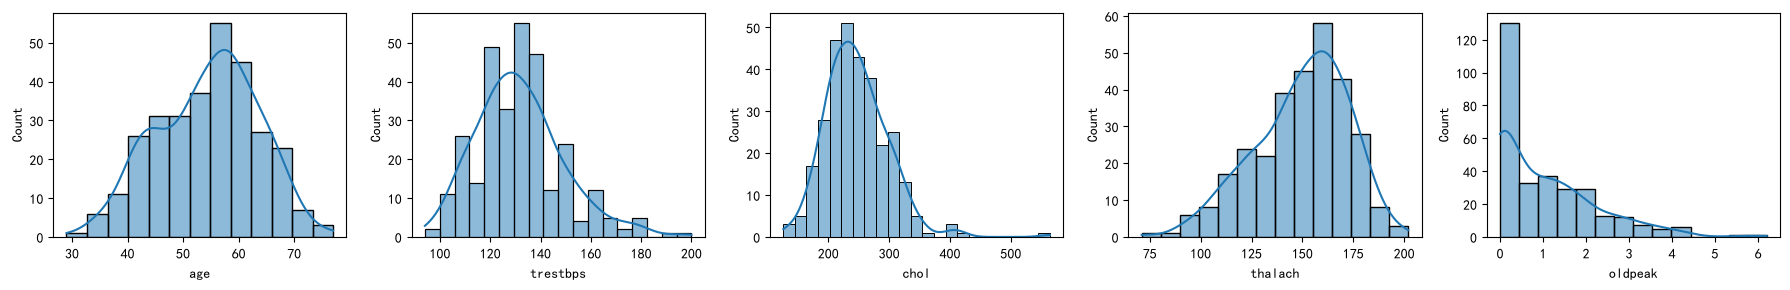

In [22]:
# 数值变量：直方图
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, c in zip(axes, num_cols):
    sns.histplot(df[c], kde=True, ax=ax)
plt.tight_layout()
plt.savefig("../figures/hist_num.png", dpi=150)
plt.show()

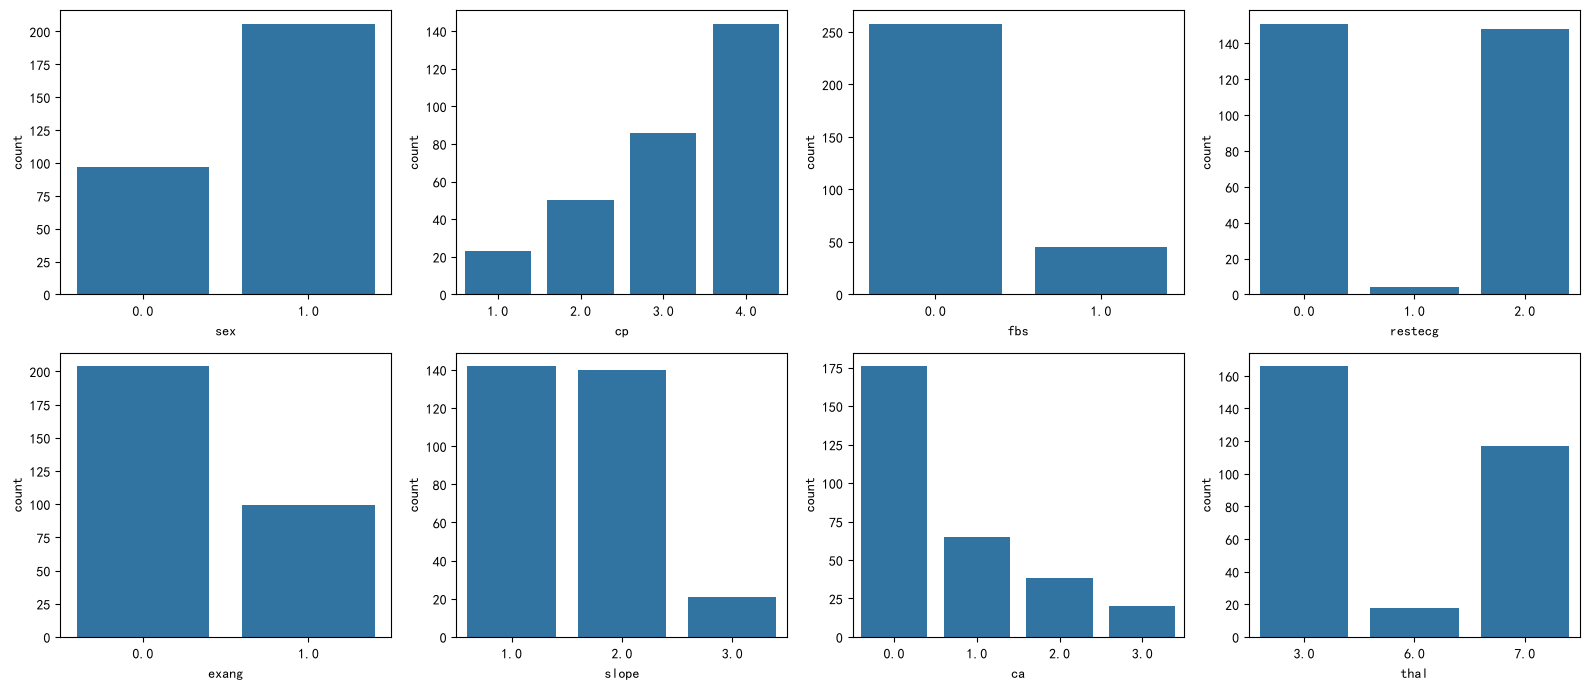

In [23]:
# 类别变量：计数条形图
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.ravel(), cat_cols):
    sns.countplot(x=df[c], ax=ax)
plt.tight_layout()
plt.savefig("../figures/count_cat.png", dpi=150)
plt.show()

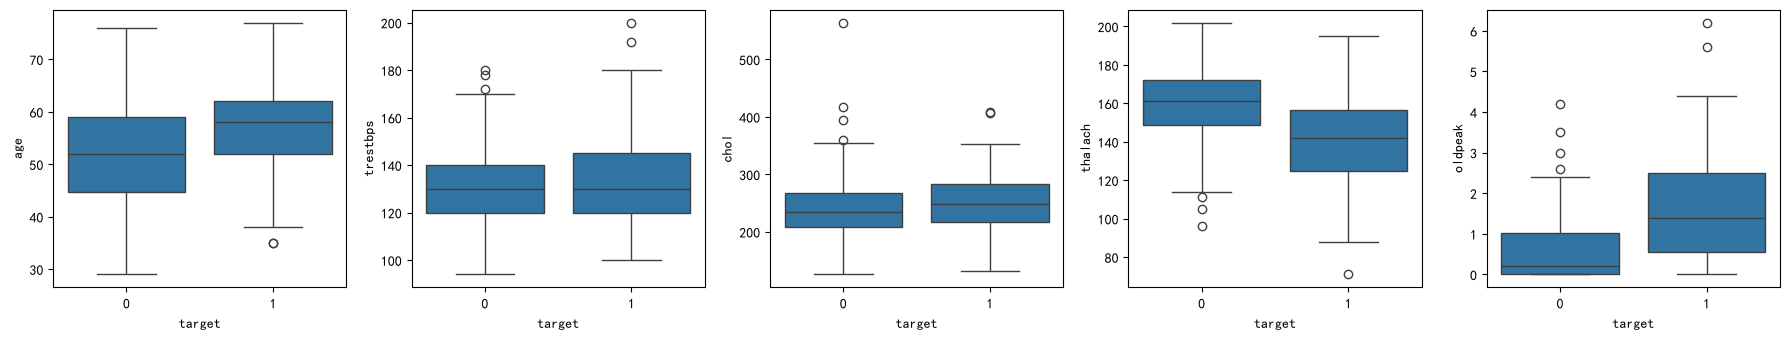

In [24]:
# 数值变量：按 target 分组的箱线图
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, c in zip(axes, num_cols):
    sns.boxplot(x="target", y=c, data=df, ax=ax)
plt.tight_layout()
plt.savefig("../figures/box_by_target.png", dpi=150)
plt.show()

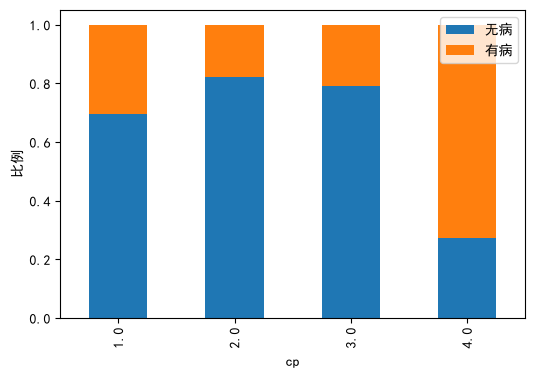

In [25]:
# 类别变量与 target：堆叠条形图（以胸痛类型 cp 为例）
pd.crosstab(df["cp"], df["target"], normalize="index").plot(
    kind="bar", stacked=True, figsize=(6, 4))
plt.ylabel("比例")
plt.legend(["无病", "有病"])
plt.savefig("../figures/cp_stacked.png", dpi=150)
plt.show()

In [26]:
from scipy import stats

print("=== 数值变量：t 检验（比较两组均值） ===")
for c in num_cols:
    g0 = df.loc[df.target == 0, c]
    g1 = df.loc[df.target == 1, c]
    t, p = stats.ttest_ind(g0, g1)
    print(f"{c:9s} t={t:6.2f} p={p:.2e} {'显著' if p < 0.05 else '不显著'}")

=== 数值变量：t 检验（比较两组均值） ===
age       t= -3.97 p=8.96e-05 显著
trestbps  t= -2.65 p=8.55e-03 显著
chol      t= -1.48 p=1.39e-01 不显著
thalach   t=  7.96 p=3.46e-14 显著
oldpeak   t= -8.13 p=1.10e-14 显著


In [27]:
print("=== 类别变量：卡方检验（比较构成比） ===")
for c in cat_cols:
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df[c], df.target))
    print(f"{c:9s} chi2={chi2:6.2f} p={p:.2e} {'显著' if p < 0.05 else '不显著'}")

=== 类别变量：卡方检验（比较构成比） ===
sex       chi2= 22.04 p=2.67e-06 显著
cp        chi2= 81.82 p=1.25e-17 显著
fbs       chi2=  0.08 p=7.81e-01 不显著
restecg   chi2= 10.05 p=6.57e-03 显著
exang     chi2= 54.69 p=1.41e-13 显著
slope     chi2= 45.78 p=1.14e-10 显著
ca        chi2= 71.84 p=1.72e-15 显著
thal      chi2= 83.29 p=8.20e-19 显著


In [28]:
rows = []
for c in num_cols:
    g0 = df.loc[df.target == 0, c]
    g1 = df.loc[df.target == 1, c]
    t, p = stats.ttest_ind(g0, g1)
    rows.append({"变量": c, "类型": "数值(t检验)", "统计量": round(t, 2), "p值": p})
for c in cat_cols:
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df[c], df.target))
    rows.append({"变量": c, "类型": "类别(卡方)", "统计量": round(chi2, 2), "p值": p})

result = pd.DataFrame(rows)
result["显著性"] = result["p值"].apply(lambda p: "显著" if p < 0.05 else "不显著")
result

,变量,类型,统计量,p值,显著性
0,age,数值(t检验),-3.97,8.955637e-05,显著
1,trestbps,数值(t检验),-2.65,8.548269e-03,显著
2,chol,数值(t检验),-1.48,1.391417e-01,不显著
3,thalach,数值(t检验),7.96,3.456965e-14,显著
4,oldpeak,数值(t检验),-8.13,1.097605e-14,显著
5,sex,类别(卡方),22.04,2.666712e-06,显著
6,cp,类别(卡方),81.82,1.251711e-17,显著
7,fbs,类别(卡方),0.08,7.812734e-01,不显著
8,restecg,类别(卡方),10.05,6.566524e-03,显著
9,exang,类别(卡方),54.69,1.413788e-13,显著


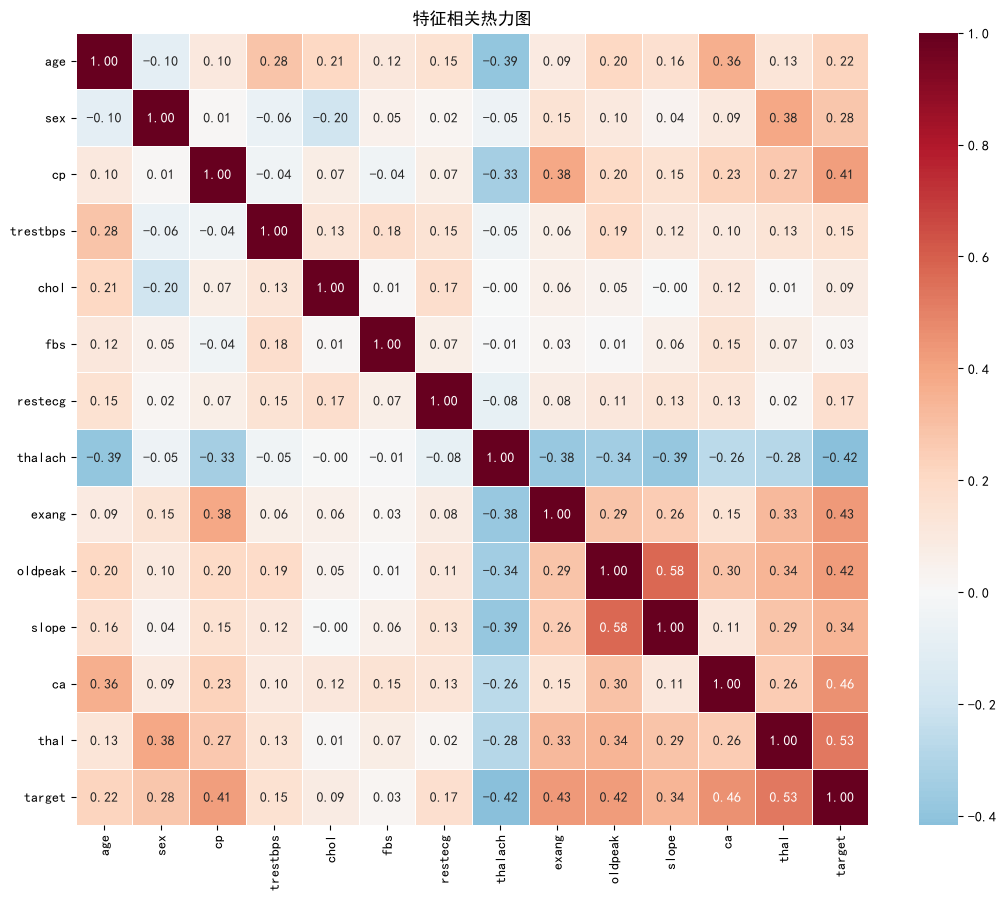

In [29]:
plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5)
plt.title("特征相关热力图")
plt.tight_layout()
plt.savefig("../figures/corr_heatmap.png", dpi=150)
plt.show()